Dataset: engineered_dataset.csv (only relational features + target).  
Goal: regression benchmarking.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier


import lightgbm as lgb

In [2]:

TARGET = "months" #months or years
if TARGET == "years":
    ERROR_MARGINS = [0.5, 1, 2]
else:
    ERROR_MARGINS = [3, 6, 9, 12]

In [3]:
#Load dataset
df = pd.read_csv("../src/data/processed/engineered_dataset.csv")

print(df.shape)
df.head()

(100000, 17)


,agreeableness_diff,career_ambition_diff,chronotype_diff,conscientiousness_diff,emotional_expressiveness_diff,extraversion_diff,openness_diff,spontaneity_diff,same_career_field,same_location,same_love_language,age_diff,large_age_gap,age_mean,education_diff,large_education_gap,relationship_longevity_months
0,0.35,0.54,0.18,0.01,0.14,0.17,0.32,0.19,0,0,0,26,1,33.0,0,0,60
1,0.31,0.14,0.02,0.14,0.11,0.39,0.07,0.16,0,0,0,6,0,35.0,1,0,59
2,0.15,0.02,0.34,0.39,0.21,0.57,0.05,0.17,0,1,0,21,1,35.5,2,1,84
3,0.26,0.15,0.37,0.60,0.06,0.07,0.13,0.25,0,0,0,18,1,29.0,2,1,70
4,0.18,0.07,0.54,0.30,0.06,0.04,0.09,0.27,0,0,1,14,1,29.0,1,0,68


In [4]:
def evaluate(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)

    return rmse, mae, r2

Split features and target

In [5]:
# --- Target selection ---
if TARGET == "months":
    y = df["relationship_longevity_months"]

elif TARGET == "years":
    if "relationship_longevity_years" not in df.columns:
        df["relationship_longevity_years"] = (
            df["relationship_longevity_months"] / 12
        )
    y = df["relationship_longevity_years"]

else:
    raise ValueError("TARGET must be 'months' or 'years'")


X = df.drop(
    columns=[
        "relationship_longevity_months",
        "relationship_longevity_years"
    ],
    errors="ignore"
)


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

print(f"Target unit: {TARGET}")
print(f"Train size: {len(X_train)}")
print(f"Test size: {len(X_test)}")

Target unit: months
Train size: 70000
Test size: 30000


# Define the evaluation metrics

# Build the models

In [6]:
baseline_pred = np.full_like(y_test, y_train.mean())

baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_r2 = r2_score(y_test, baseline_pred)

metrics_results = [{
    "Model": "Baseline_Mean",
    "RMSE": baseline_rmse,
    "MAE": baseline_mae,
    "R2": baseline_r2
}]

In [7]:
models = {
    "Linear": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.01),
    "RandomForest": RandomForestRegressor(
        n_estimators=200,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    ),
    "LightGBM": lgb.LGBMRegressor(
        n_estimators=500,
        learning_rate=0.05,
        random_state=42
    )
}

# Results

In [8]:
predictions = {}
metrics_results = []

for name, model in models.items():
    
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    # Stock predictions
    predictions[name] = preds
    
    # Classical metrics
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    
    metrics_results.append({
        "Model": name,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    })

metrics_df = pd.DataFrame(metrics_results).sort_values("RMSE")
metrics_df

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002609 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1313
[LightGBM] [Info] Number of data points in the train set: 70000, number of used features: 16
[LightGBM] [Info] Start training from score 68.842429


,Model,RMSE,MAE,R2
0,Linear,19.970967,16.004959,0.117231
1,Ridge,19.970975,16.004969,0.117230
2,Lasso,19.972634,16.006634,0.117083
4,LightGBM,20.042601,16.074220,0.110887
3,RandomForest,20.199298,16.182866,0.096930


## Results interpretation (target MONTHS)
Linear models (Linear, Ridge, Lasso) show similar results and are very slightly more efficient than tree-based models. Meaning, the dataset likely does not contain strong non-linear interactions between features.

Metrics : 
- Mean Absolute Error of 16 months
- Root Mean Squared Error 20 i.e. some errors are important as RMSE > MAE
- R2 : 11,7% Low r2 
=> The model explains a modest portion of variability.

# Adapting the model evaluation with a more business oriented metric

The target is in month, from 0 to 120, which is a highly granular level. Let's widen the models' success target by taking an error margin into account. 
Let's take +/- ERROR_MARGIN months of acceptable error and compare the models which hits successfully in these ranges.

In [9]:
business_results = []

for name, preds in predictions.items():
    
    row = {"Model": name}
    abs_error = np.abs(y_test - preds)
    
    for margin in ERROR_MARGINS:
        row[f"Within_±{margin}{TARGET}"] = (abs_error <= margin).mean()
    
    business_results.append(row)

business_df = pd.DataFrame(business_results)

business_df = business_df.round(3)

business_df

,Model,Within_±3months,Within_±6months,Within_±9months,Within_±12months
0,Linear,0.119,0.235,0.343,0.447
1,Ridge,0.119,0.235,0.343,0.447
2,Lasso,0.119,0.234,0.343,0.448
3,RandomForest,0.116,0.229,0.340,0.444
4,LightGBM,0.117,0.233,0.342,0.444


## Comparison (target MONTHS)
All models show similar performances, confiming the signal is mostly linear. 
The monthly granularity is too precise as only 12% of predictions are correct for a margin of 3 months. 
However, enlarging the margin gives us interesting results as almost half of the predictions become correct with a large margin of 12 months.

Although LightGBM is the less performant one here (but with really little difference with other models), we will continue with this model from now on as advantages of LightGBM are its robustness, stability to feature scaling, and production-readiness (fast inference, SHAP explainability).

# Model vs Baseline using business evaluation metric

In [10]:
results_new_metric = []
abs_errors_baseline = np.abs(y_test - np.full_like(y_test, y_train.mean()))
abs_errors_linear   = np.abs(y_test - predictions["Linear"])
abs_errors_lgb      = np.abs(y_test - predictions["LightGBM"])

for name, errors in {
    "Baseline": abs_errors_baseline,
    "Linear": abs_errors_linear,
    "LightGBM": abs_errors_lgb
}.items():
    
    row = {"Model": name}
    
    for margin in ERROR_MARGINS:
        row[f"≤ {margin} {TARGET}"] = np.mean(errors <= margin)
    
    results_new_metric.append(row)

results_new_metric_df = pd.DataFrame(results_new_metric)
results_new_metric_df = results_new_metric_df.round(3)

results_new_metric_df

,Model,≤ 3 months,≤ 6 months,≤ 9 months,≤ 12 months
0,Baseline,0.131,0.240,0.342,0.439
1,Linear,0.119,0.235,0.343,0.447
2,LightGBM,0.117,0.233,0.342,0.444



📊 % of predictions within acceptable margin

Model             ≤ 3 months      ≤ 6 months      ≤ 9 months     ≤ 12 months
----------------------------------------------------------------------------
Baseline        13.1%  ← baseline    24.0%  ← baseline    34.2%  ← baseline    43.9%  ← baseline
Linear          11.9%  (-1.2%)    23.5%  (-0.5%)    34.3%  (+0.1%)    44.7%  (+0.8%)
LightGBM        11.7%  (-1.4%)    23.3%  (-0.7%)    34.2%  (+0.0%)    44.4%  (+0.5%)

⚠️  Positive values mean the model beats the baseline — none do here.



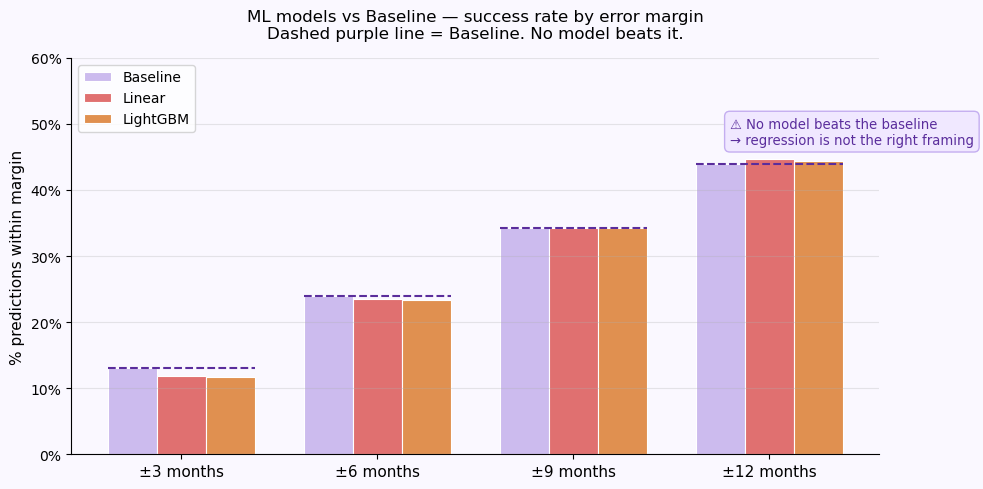


→ Conclusion: even with a ±12-month margin, no model outperforms simply predicting the mean.
   This confirms that regression on monthly duration is the wrong framing — pivot to binary classification.


In [11]:
# ⚠️ No model beats the baseline — % of predictions within acceptable margin

viz_df = results_new_metric_df.copy()
margin_cols = [c for c in viz_df.columns if c != "Model"]
viz_df[margin_cols] = (viz_df[margin_cols] * 100).round(1).astype(str) + "%"
viz_df

### /!\ The models are not better than the Baseline.

We need to explore another approach to this problem. The monthly target may be too granular to be used as if, next we'll try categorizing it.

Additional exploration: The same analysis can be performed using a target converted to years by modifying the TARGET constant.
While the results are slightly improved, the performance gain remains limited and tends us to try a more larger categorical approach.


# Problem Reframing

Initial experiments tried to predict the exact relationship duration (in years).

However, the target distribution is heavily concentrated in the middle (mostly 3–6 years), with very few extreme cases. As a result, the baseline (predicting the mean) is already strong, and more complex models only bring marginal improvements.

This suggests that the issue is not model capacity, but the structure of the target itself (limited variance).

Instead of predicting exact longevity, we now reframe the problem as a classification task: predicting whether a relationship is “long-lasting” relative to a chosen threshold.

This formulation is more stable, more interpretable, and better aligned with a realistic prediction objective.